In [1]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import datetime
import glob
import os
from scipy.stats import binned_statistic_2d
from scipy import stats
import pickle as pkl
from scipy.stats import gaussian_kde, linregress
import importlib
from shared.LMCS import glob_util
from shared.paths import load_paths

%matplotlib inline

In [45]:
REGIONS = glob_util.REGIONS
style = glob_util.REGION_STYLE

YEARS = range(2000,2020)

In [4]:
paths = load_paths()
outfig = paths["shear_study"]

In [5]:
def read_env_var(root, var, region, year):
    path = f"{root}/{var}/region={region}/year={year}/part.parquet"

    print("Reading:")
    print(path)

    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    df = pd.read_parquet(path,engine="fastparquet")
    df = df.rename(columns={"value": var})

    print("Regions inside file:", df["region"].unique())

    return df.copy()

In [6]:
def read_meta(region):
    files = [
        f"{ROOT}/storm_metadata/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [pd.read_parquet(f) for f in files],
        ignore_index=True
    )

def read_var(var, region):
    files = [
        f"{ROOT}/{var}/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [
            pd.read_parquet(
                f,
                columns=["storm_id", "rel_hour", "value"]
            )
            for f in files
        ],
        ignore_index=True
    )


def region_df(region, rel_hour=0):
    df = read_meta(region).copy()

    for var in ERA_VARS:
        tmp = read_var(var, region)

        tmp = (
            tmp[tmp["rel_hour"] == rel_hour]
            [["storm_id", "value"]]
            .drop_duplicates("storm_id")
            .rename(columns={"value": var})
        )

        df = df.merge(tmp, on="storm_id", how="left")

    df["region"] = region

    return df

In [7]:
def build_all_regions(variables):

    dfs = []

    for region in REGIONS:

        meta = read_meta(region)

        if meta is None:
            continue

        df = None

        for var in variables:

            tmp = read_var(var, region)

            tmp = tmp.rename(columns={"value": var})

            if df is None:
                df = tmp
            else:
                df = df.merge(
                    tmp[["storm_id", "rel_hour", var]],
                    on=["storm_id", "rel_hour"],
                    how="outer",
                )

        df = df.merge(meta, on="storm_id", how="left")

        df["region"] = region

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [11]:
ROOT = paths.datasets["obs_mcs_5000km2_tables_ERA"]
ERA_VARS = ["q925"]

all_list = []
for reg in REGIONS:
    reg_df = region_df(reg, rel_hour=0)
    all_list.append(reg_df)
df_all = pd.concat(all_list, ignore_index=True)

In [12]:
df_all.keys()

Index(['date', 'month', 'hour', 'minute', 'year', 'day', 'area', 'area70',
       'area60', 'area50', 'minlon', 'minlat', 'maxlon', 'maxlat', 'clon',
       'clat', 'tminlon', 'tminlat', 'tmin', 'tmean', 'tp1', 'tp99', 'stormID',
       'shape_complexity', 'major_axis_km', 'minor_axis_km', 'aspect_ratio',
       'precipitation_mean', 'precipitation_max', 'precipitation_p80',
       'precipitation_p90', 'precipitation_p95', 'precipitation_p99',
       'precipitation_area1mm', 'precipitation_area3mm',
       'precipitation_area8mm', 'region', 'storm_id', 'storm_utc_time',
       'storm_lt_time', 'storm_utc_hour', 'storm_lt_hour', 'lsm',
       'topographic_complexity', 'topographic_complexity_sdfor_slor', 'q925'],
      dtype='str')

In [52]:
df_all = df_all[(df_all['precipitation_max']>=2)]

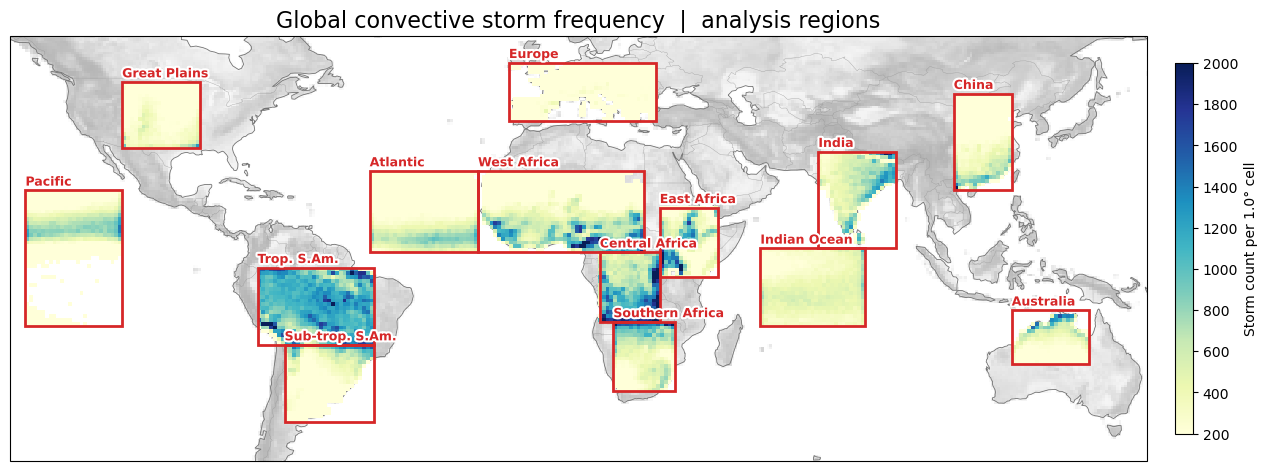

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

paths = load_paths()
ds_static = xr.open_dataset(paths.datasets["era5_0.7_static"] + "/era5_invariant_07deg_COCOON-study_regrid.nc")


# one row per storm if this is a variable-timeseries parquet
plot_df = df_all.drop_duplicates("storm_id").copy()

GRID_RES = 1.0

lon_bins = np.arange(-180, 181, GRID_RES)
lat_bins = np.arange(-60, 61, GRID_RES)

H, xedges, yedges = np.histogram2d(
    plot_df["tminlon"],
    plot_df["tminlat"],
    bins=[lon_bins, lat_bins],
)

H = H.T
H = np.ma.masked_where(H == 0, H)   # key bit: hide zero-storm cells

fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
#ccrs.PlateCarree()
#ccrs.Robinson()
#ax.set_global()
ax.set_extent([-139, 155, -50, 60],crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="0.95")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.coastlines(linewidth=0.6, color="0.45")
ax.add_feature(cfeature.BORDERS, linewidth=0.25, edgecolor="0.6")

# ============================================================
# TOPOGRAPHIC COMPLEXITY BACKGROUND
# ============================================================

topo = ds_static["topographic_complexity"].squeeze()
topo_plot = np.log1p(topo)

# optional: log-transform because topo complexity
# is often extremely skewed


# weak greyscale background
ax.pcolormesh(
    topo["longitude"],
    topo["latitude"],
    topo_plot,
    transform=ccrs.PlateCarree(),
    cmap="Greys",
    shading="auto",
    alpha=0.28,
    zorder=0,
)

# ============================================================

cmap = plt.cm.YlGnBu.copy()  #YlOrRd, Spectral_r
cmap.set_bad(alpha=0.0)

mesh = ax.pcolormesh(
    xedges,
    yedges,
    H,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="auto",
    zorder=2,
    vmax=2000,
    vmin=200
)

cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.65, pad=0.02)
cbar.set_label(f"Storm count per {GRID_RES}° cell")

ax.add_feature(cfeature.LAND, facecolor="0.96")

label_names = {
    "GPlains": "Great Plains",
    "Eur" : "Europe",
    "WAf": "West Africa",
    "SAf": "Southern Africa",
    "sub_SA": "Sub-trop. S.Am.",
    "trop_SA": "Trop. S.Am.",
    "CAf": "Central Africa",
    "EAf": "East Africa",
    "Atl": "Atlantic",
    "Pcf": "Pacific",
    "InO": "Indian Ocean",
    "china": "China",
    "india": "India",
    "australia": "Australia",
}

for region, info in REGIONS.items():
    lon1, lon2, lat1, lat2 = info[0]

    rect = Rectangle(
        (lon1, lat1),
        lon2 - lon1,
        lat2 - lat1,
        fill=False,
        linewidth=2.0,
        edgecolor="tab:red",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )
    ax.add_patch(rect)

    ax.text(
        lon1,
        lat2 + 1.2,
        label_names.get(region, region),
        transform=ccrs.PlateCarree(),
        fontsize=9,
        fontweight="bold",
        color="tab:red",
        zorder=6,
        path_effects=[
            pe.withStroke(linewidth=3, foreground="white")
        ],
    )

ax.set_title("Global convective storm frequency  |  analysis regions", fontsize=16)
plt.tight_layout()
plt.show()
fig.savefig(outfig + "global_storm_frequency_map.png", dpi=300)

In [15]:
outfig

'{user_figs}/COCOON/shear-humidity-study/'